# AI-Powered Business Intelligence & Decision Support System

## Problem Statement
Most businesses collect large amounts of sales and customer data but lack the tools to extract meaningful insights from it.
This system bridges that gap by combining data analytics, machine learning and AI-generated insights to support smarter, faster business decisions.

## Objectives
1. Analyse sales performance across products and regions
2. Segment customers using RFM analysis
3. Predict future sales and demand
4. Auto-generate plain English business insights
5. Recommend actions based on data patterns

## Dataset
Source: Olist Brazilian E-Commerce Dataset (Kaggle)
Context: Adapted to simulate a Nigerian e-commerce business intelligence environment


# IMPORT MY NECESSARY DEPENDENCIES


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from groq import Groq
import mysql.connector
from sqlalchemy import create_engine

In [2]:
#CORE TRANSACTIONAL FILES
items = pd.read_csv("C:/Users/User PC/Downloads/Business_Intelligence_System/olist_order_items_dataset.csv")
payment = pd.read_csv("C:/Users/User PC/Downloads/Business_Intelligence_System/olist_order_payments_dataset.csv")
orders = pd.read_csv("C:/Users/User PC/Downloads/Business_Intelligence_System/olist_orders_dataset.csv")

#PRODUCT FILES
product_cat = pd.read_csv("C:/Users/User PC/Downloads/Business_Intelligence_System/product_category_name_translation.csv")
products = pd.read_csv("C:/Users/User PC/Downloads/Business_Intelligence_System/olist_products_dataset.csv")

#SELLE RAND CUSTOMER FILES
sellers = pd.read_csv("C:/Users/User PC/Downloads/Business_Intelligence_System/olist_sellers_dataset.csv")
customer = pd.read_csv("C:/Users/User PC/Downloads/Business_Intelligence_System/olist_customers_dataset.csv")

#SUPPORTING FILES
reviews = pd.read_csv("C:/Users/User PC/Downloads/Business_Intelligence_System/olist_order_reviews_dataset.csv")
geo_location = pd.read_csv("C:/Users/User PC/Downloads/Business_Intelligence_System/olist_geolocation_dataset.csv")


print("All dataset loaded succesfully")

All dataset loaded succesfully


##  Data Loading & Overview


### 1. Items Dataset
- Shape: 112,650 rows × 7 columns
- Contains order-level product details including price and freight value
- Freight value is simply the delivery/shipping fee charged on each order. Like when you order on Jumia and they add a delivery fee on top of the product price.
- shipping_limit_date stored as string — needs conversion

### 2. Payment Dataset
- Shape: 103,886 rows × 5 columns
- Contains payment method, installments and payment value per order
- Most transactions paid via credit card

### 3. Orders Dataset
- Shape: 99,441 rows × 8 columns
- Contains order status and all date-related information
- All date columns stored as strings — needs conversion
- Some delivery date columns appear to have missing entries

### 4. Product Category Translation Dataset
- Shape: 71 rows × 2 columns
- Columns: product_category_name (Portuguese), 
  product_category_name_english (English)
- No missing values
- Contains 71 unique product categories
- Will be used to translate product names in cleaning phase

### 5. Products Dataset
- Shape: 32,951 rows × 9 columns
- Columns: product_id, product_category_name,product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm,
  product_height_cm, product_width_cm
- Missing values detected in category and description columns
- Product category names currently in Portuguese

### 6. Sellers Dataset
- Shape: 3,095 rows × 4 columns
- Columns: seller_id, seller_zip_code_prefix, seller_city, seller_state
- No missing values
- Only 3,095 sellers serving ~100k oration7
### 6. Customers Dataset
- Shape: 99,441 rows × 5 columns
- Columns: customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state
- No missegmentation
- 99,441 rows matches orders dataset exactly — clean one-to-on8 join

### 7. Reviews Dataset
- Shape: 99,224 rows × 7 columns
- Columns: review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp
- Heavy missing values in review_comment_title and review_comment_message — most customers skip written feedback
- Date columns stored as strings — cowhen cleaning worth 9nvestigating

### 8. Geolocation Dataset
- Shape: 1,000,163 rows × 5 columns
- Columns: geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_stafix — hence the 1M+ rows
- Not merged into main dataset — reserved for Povisualisations in Phase 11

### Key Observations
- All 3 files share order_id as the common merge key
- Date columns need to be converted to datetime across all files
- Missing values spotted in orders
- product_cat will be used to translate product names in products
- Missing values in products t
- customer_id and customer_unique_id serve different purposes —to be  handlde carefully in segmentation
- Reviews contain significant missing values in text columnor
- Geolocation is a standalone mapping file — not part of the main merge be confirmed and handled 

In [3]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [4]:
items.shape

(112650, 7)

In [5]:
items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [6]:
items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [7]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [8]:
payment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [9]:
payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [10]:
payment.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [11]:
payment.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [12]:
payment.shape

(103886, 5)

In [13]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [14]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [15]:
orders.shape

(99441, 8)

In [16]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [17]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [18]:
product_cat.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [19]:
product_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [20]:
product_cat.shape

(71, 2)

In [21]:
product_cat.columns

Index(['product_category_name', 'product_category_name_english'], dtype='object')

In [22]:
product_cat.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [23]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [24]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [25]:
products.shape

(32951, 9)

In [26]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [27]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [28]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [29]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [30]:
sellers.shape

(3095, 4)

In [31]:
sellers.columns

Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')

In [32]:
sellers.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [33]:
customer.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [34]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [35]:
customer.shape

(99441, 5)

In [36]:
customer.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [37]:
customer.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [38]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [39]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [40]:
reviews.shape

(99224, 7)

In [41]:
reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

In [42]:
reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [43]:
geo_location.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [44]:
geo_location.shape

(1000163, 5)

In [45]:
geo_location.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [46]:
geo_location.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [47]:
geo_location.columns

Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')

In [48]:
items.isnull().sum() # NO MISSING VALUES


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [49]:
payment.isnull().sum()


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [50]:
orders.isnull().sum() #MISSING VALUES


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [51]:
product_cat.isnull().sum()


product_category_name            0
product_category_name_english    0
dtype: int64

In [52]:
products.isnull().sum() #MISSING VALUES
 

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [53]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [54]:
customer.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [55]:
reviews["review_comment_title"].unique()

array([nan, 'recomendo', 'Super recomendo', ...,
       'Não foi entregue o pedido', 'OTIMA EMBALAGEM', 'Foto enganosa '],
      dtype=object)

In [56]:
reviews.isnull().sum() #MISSING VALUES


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [57]:
geo_location.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [58]:
items.duplicated().sum() #CHECKING FOR DUPICATE VALUES


0

In [59]:
payment.duplicated().sum()


0

In [60]:
orders.duplicated().sum()


0

In [61]:
product_cat.duplicated().sum()


0

In [62]:
products.duplicated().sum()


0

In [63]:
sellers.duplicated().sum()


0

In [64]:
customer.duplicated().sum()


0

In [65]:
reviews.duplicated().sum()


0

In [66]:
geo_location.duplicated().sum() # DUPLICATED VALUES FOUND

261831

##  Data Cleaning

### Missing Values
- orders: Dropped 160 rows where order_approved_at was missing.
  Delivery date columns left as NaT after datetime conversion — representing cancelled or in-transit orders
- products: Dropped 2 rows with missing dimension values.
  Filled 610 missing category names with 'Unknown'.
  Filled 610 missing name length, description length and photos quantity with median values
- reviews: Filled 87,656 missing comment titles with 'No Title'. Filled 58,247 missing comment messages with 'No Comment'
- All other files had no missing values

### Duplicates
- geolocation: Dropped 261,831 duplicate rows
- All other files had zero duplicates

### Date Conversions
- orders: Converted all 5 date columns to datetime64
- items: Converted shipping_limit_date to datetime64
- reviews: Converted review_creation_date and  review_answer_timestamp to datetime64

### Product Translation
- Merged products with product_cat to translate category names from Portuguese to English
- Dropped Portuguese category column
- 622 unmatched categories filled with 'Unknown'

### Outlier Handling
- items: Removed outliers in price using IQR method. Rows reduced from 112,650 to 104,223
- payment: Removed 3 rows where payment type was 'not_defined' and payment value was 0.
- Removed outliers in payment_value using IQR method. Rows reduced from 103,886 to 95,902

### Column Standardization
- Standardized column names across all 8 dataframes — stripped whitespace, lowercased, replaced spaces with underscores

### Phase 3 Summary
- All missing values handled
- All duplicates removed
- All date columns converted to correct format
- Product names translated to English
- Outliers removed from price and payment value
- Column names standardized across all datasets

In [67]:
#HANDLING NULLS

In [68]:
orders["order_status"].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [69]:
orders = orders.dropna(subset = ["order_approved_at"]) #dropped 160 rows

In [70]:
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"]) 
#CONVERTED TO THE CORRECT DATA FORMAT

In [71]:
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
#CONVERTED TO THE CORRECT DATA FORMAT

In [72]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
#CONVERTED TO THE CORRECT DATA FORMAT

In [73]:
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])
#CONVERTED TO THE CORRECT DATA FORMAT

In [74]:
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])
#CONVERTED TO THE CORRECT DATA FORMAT

In [75]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99281 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99281 non-null  object        
 1   customer_id                    99281 non-null  object        
 2   order_status                   99281 non-null  object        
 3   order_purchase_timestamp       99281 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97644 non-null  datetime64[ns]
 6   order_delivered_customer_date  96462 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99281 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.8+ MB


In [76]:
#HANDLING MISSING VALUES FOR THE PRODUCT DATASET

In [77]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [78]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [79]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [80]:
products = products.dropna(subset =["product_height_cm", "product_width_cm" ,"product_length_cm", "product_weight_g"])

In [81]:
cols = ["product_name_lenght", "product_description_lenght", "product_photos_qty"]
products[cols] = products[cols].fillna(products[cols].median())

In [82]:
products["product_category_name"] = products["product_category_name"].fillna("unknown")

In [83]:
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [84]:
#HANDLING MISSING VALUES FOR THE REVIEW DATSET

In [85]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [86]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [87]:
reviews["review_comment_title"] = reviews["review_comment_title"]. fillna("No Title") #FILLED OUR MISSING VALUES

In [88]:
reviews["review_comment_message"] = reviews["review_comment_message"]. fillna("No Message")

In [89]:
reviews.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [90]:
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"]) #CONVERTED TO THE CORRECT D TYPE

In [91]:
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"]) #CONVERTED TO THE CORRECT D TYPE

In [92]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Message,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Message,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No Message,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [93]:
# CONVERT SHIPPING LIMIT ITEMS TO DATE TIME

In [94]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [95]:
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"])

In [96]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [97]:
#DROPPED DUPLICATES IN GEO_LOCATION

In [98]:
geo_location = geo_location.drop_duplicates()

In [99]:
geo_location.duplicated().sum()

0

In [100]:
# MERGED PRODUCTS WITH PRODUCT_CAT TO TRANSLATE CATEGORY NAMES 
# FROM PORTUGUESE TO ENGLISH, THEN DROPPED THE PORTUGUESE COLUMN

In [101]:
products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32949 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32949 non-null  object 
 1   product_category_name       32949 non-null  object 
 2   product_name_lenght         32949 non-null  float64
 3   product_description_lenght  32949 non-null  float64
 4   product_photos_qty          32949 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB


In [102]:
product_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [103]:
product = pd.merge(products, product_cat, on = "product_category_name", how = "outer")

In [104]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32949 entries, 0 to 32948
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32949 non-null  object 
 1   product_category_name          32949 non-null  object 
 2   product_name_lenght            32949 non-null  float64
 3   product_description_lenght     32949 non-null  float64
 4   product_photos_qty             32949 non-null  float64
 5   product_weight_g               32949 non-null  float64
 6   product_length_cm              32949 non-null  float64
 7   product_height_cm              32949 non-null  float64
 8   product_width_cm               32949 non-null  float64
 9   product_category_name_english  32327 non-null  object 
dtypes: float64(7), object(3)
memory usage: 2.5+ MB


In [105]:
product = product.drop("product_category_name", axis = 1)

In [106]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32949 entries, 0 to 32948
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32949 non-null  object 
 1   product_name_lenght            32949 non-null  float64
 2   product_description_lenght     32949 non-null  float64
 3   product_photos_qty             32949 non-null  float64
 4   product_weight_g               32949 non-null  float64
 5   product_length_cm              32949 non-null  float64
 6   product_height_cm              32949 non-null  float64
 7   product_width_cm               32949 non-null  float64
 8   product_category_name_english  32327 non-null  object 
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [107]:
product.isnull().sum()

product_id                         0
product_name_lenght                0
product_description_lenght         0
product_photos_qty                 0
product_weight_g                   0
product_length_cm                  0
product_height_cm                  0
product_width_cm                   0
product_category_name_english    622
dtype: int64

In [108]:
product["product_category_name_english"] = product ["product_category_name_english"]. fillna("Unknown")
# AFTER MERGING, DISCOVEREED THERE WAS MISSING VALUES

In [109]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32949 entries, 0 to 32948
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32949 non-null  object 
 1   product_name_lenght            32949 non-null  float64
 2   product_description_lenght     32949 non-null  float64
 3   product_photos_qty             32949 non-null  float64
 4   product_weight_g               32949 non-null  float64
 5   product_length_cm              32949 non-null  float64
 6   product_height_cm              32949 non-null  float64
 7   product_width_cm               32949 non-null  float64
 8   product_category_name_english  32949 non-null  object 
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [110]:
#HANDLING OUTLIERS

In [111]:
# DROPPING 3 ROWS WHERE PAYMENT TYPE IS 'not_defined' 
# AND PAYMENT VALUE IS 0 — UNUSABLE DATA

In [112]:
payment[payment["payment_value"] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [113]:
payment[payment["payment_type"] == "not_defined"]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


In [114]:
payment = payment[~((payment["payment_type"] == "not_defined") & (payment["payment_value"] == 0))]
# DROPPED 3 ROWS WHERE PAYMENT TYPE IS 'not_defined' 
# AND PAYMENT VALUE IS 0 — UNUSABLE DATA
#BOOLEAN FILTERING

In [115]:
payment.shape  # should show 103,883 (lost 3 rows)

(103883, 5)

In [116]:
payment[payment["payment_type"] == "not_defined"]  # should return empty

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [117]:
# HANDLING OUTLIERS IN PRICE USING IQR METHOD
Q1 = items["price"].quantile(0.25)
Q3 = items["price"].quantile(0.75)
IQR = Q3 - Q1
items = items[(items["price"] >= Q1 - 1.5 * IQR) & (items["price"] <= Q3 + 1.5 * IQR)]

In [118]:
# HANDLING OUTLIERS IN PAYMENT VALUE USING IQR METHOD
Q1 = payment["payment_value"].quantile(0.25)
Q3 = payment["payment_value"].quantile(0.75)
IQR = Q3 - Q1
payment = payment[(payment["payment_value"] >= Q1 - 1.5 * IQR) & (payment["payment_value"] <= Q3 + 1.5 * IQR)]

In [119]:
items.shape

(104223, 7)

In [120]:
payment.shape

(95902, 5)

In [121]:
# STANDARDIZING COLUMN NAMES
items.columns = items.columns.str.strip().str.lower().str.replace(" ", "_")
payment.columns = payment.columns.str.strip().str.lower().str.replace(" ", "_")
orders.columns = orders.columns.str.strip().str.lower().str.replace(" ", "_")
customer.columns = customer.columns.str.strip().str.lower().str.replace(" ", "_")
product.columns = product.columns.str.strip().str.lower().str.replace(" ", "_")
sellers.columns = sellers.columns.str.strip().str.lower().str.replace(" ", "_")
reviews.columns = reviews.columns.str.strip().str.lower().str.replace(" ", "_")
geo_location.columns = geo_location.columns.str.strip().str.lower().str.replace(" ", "_")

In [122]:
items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

## Phase 4 — Exploratory Data Analysis & Visualization

### Charts Produced
1. Revenue Trends Over Time — line chart showing monthly revenue from 2016 to 2018
2. Monthly Revenue Growth — bar chart showing percentage change month over month
3. Top 10 Best Performing Products — horizontal bar chart ranked  by total revenue
4. Top 10 Worst Performing Products — horizontal bar chart ranked by lowest revenue
5. Regional Performance by State — bar chart showing revenue per customer state
6. Order Status Distribution — bar chart showing order status counts
7. Payment Type Distribution — pie chart showing payment method breakdown
8. Customer Order Frequency — histogram showing how often customers order
9. Correlation Heatmap — showing relationships between price, 
   freight value and order item id

### Key Insights
- Revenue grew steadily through 2017, peaking in November 2017
- bed_bath_table is the highest revenue product category
- computers is the worst performing product category
- São Paulo (SP) generates significantly more revenue than all other states
- 97% of orders are successfully delivered
- 73% of customers pay by credit card
- Almost all customers have only ordered once — high churn risk
- Price and freight value have a moderate positive correlation of 0.34

In [123]:
# DATA VISUALIZATION

In [124]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99281 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99281 non-null  object        
 1   customer_id                    99281 non-null  object        
 2   order_status                   99281 non-null  object        
 3   order_purchase_timestamp       99281 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97644 non-null  datetime64[ns]
 6   order_delivered_customer_date  96462 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99281 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.8+ MB


In [125]:
items.info()

<class 'pandas.core.frame.DataFrame'>
Index: 104223 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             104223 non-null  object        
 1   order_item_id        104223 non-null  int64         
 2   product_id           104223 non-null  object        
 3   seller_id            104223 non-null  object        
 4   shipping_limit_date  104223 non-null  datetime64[ns]
 5   price                104223 non-null  float64       
 6   freight_value        104223 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.4+ MB


In [126]:
# REVENUE TRENDS OVER TIME

In [127]:
#MERGING ORDER AND ITEMS
orders_items = pd.merge(orders, items, on = "order_id", how = "inner")

In [128]:
# EXTRACTING MONTH AND YEAR
orders_items["year_month"] = orders_items["order_purchase_timestamp"].dt.to_period("M")

In [129]:
# GROUPING BY MONTH AND SUMMING REVENUE
monthly_revenue = orders_items.groupby("year_month")["price"].sum()

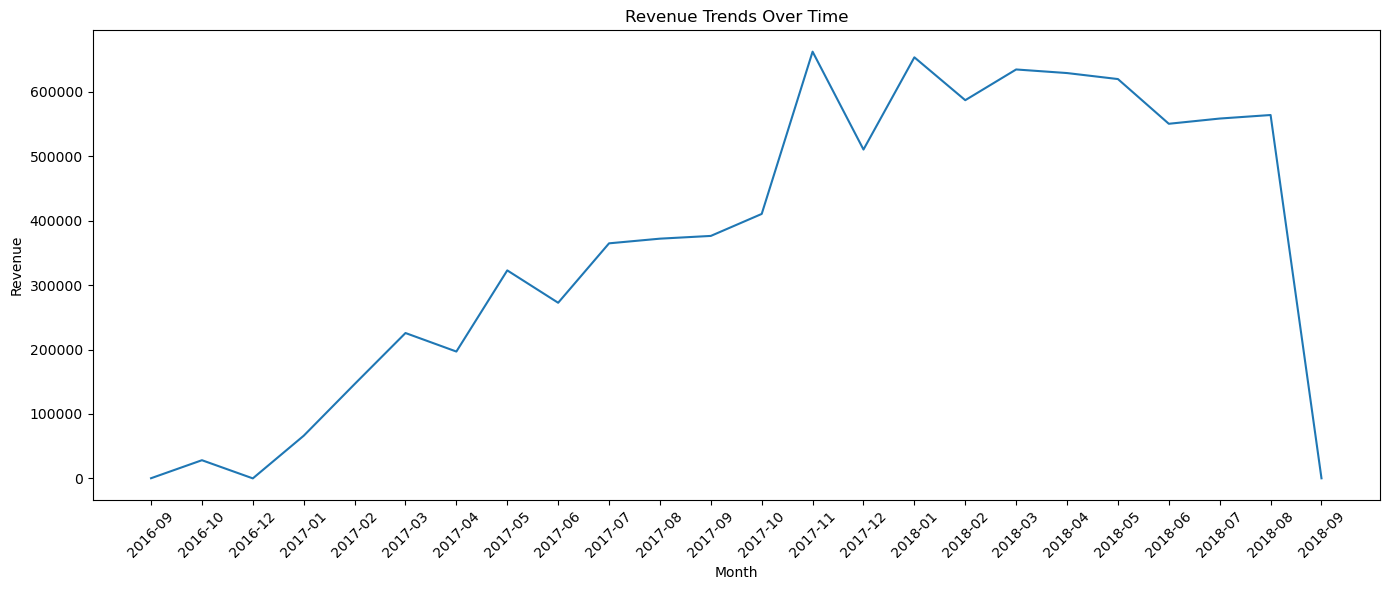

In [130]:
# PLOTTING REVENUE TRENDS OVER TIME
plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)
plt.title("Revenue Trends Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

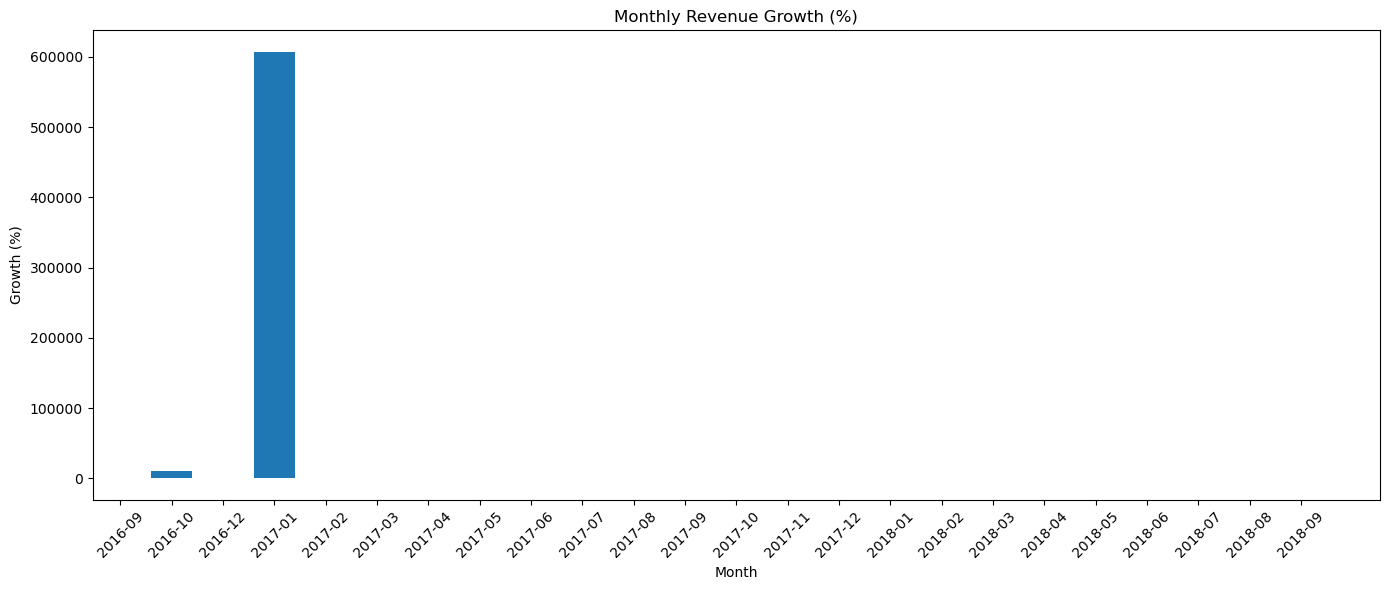

In [131]:
#MONTHLY REVENEUE GROWTH
monthly_growth = monthly_revenue.pct_change() * 100 #percentage change

plt.figure(figsize=(14, 6))
plt.bar(monthly_growth.index.astype(str), monthly_growth.values)
plt.title("Monthly Revenue Growth (%)")
plt.xlabel("Month")
plt.ylabel("Growth (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

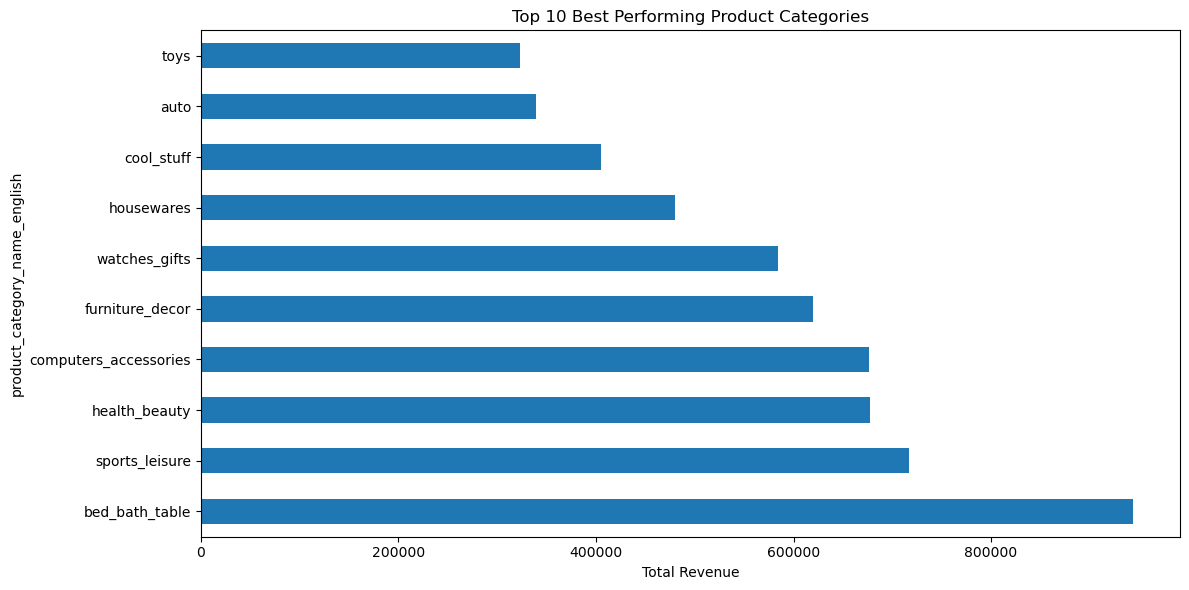

In [132]:
#  TOP 10 BEST PERFORMING PRODUCTS

# MERGING ITEMS AND PRODUCTS
items_products = pd.merge(items, product, on="product_id", how="inner")

# TOP 10 BEST PERFORMING PRODUCTS
top_products = items_products.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_products.plot(kind="barh")
plt.title("Top 10 Best Performing Product Categories")
plt.xlabel("Total Revenue")
plt.tight_layout()
plt.show()



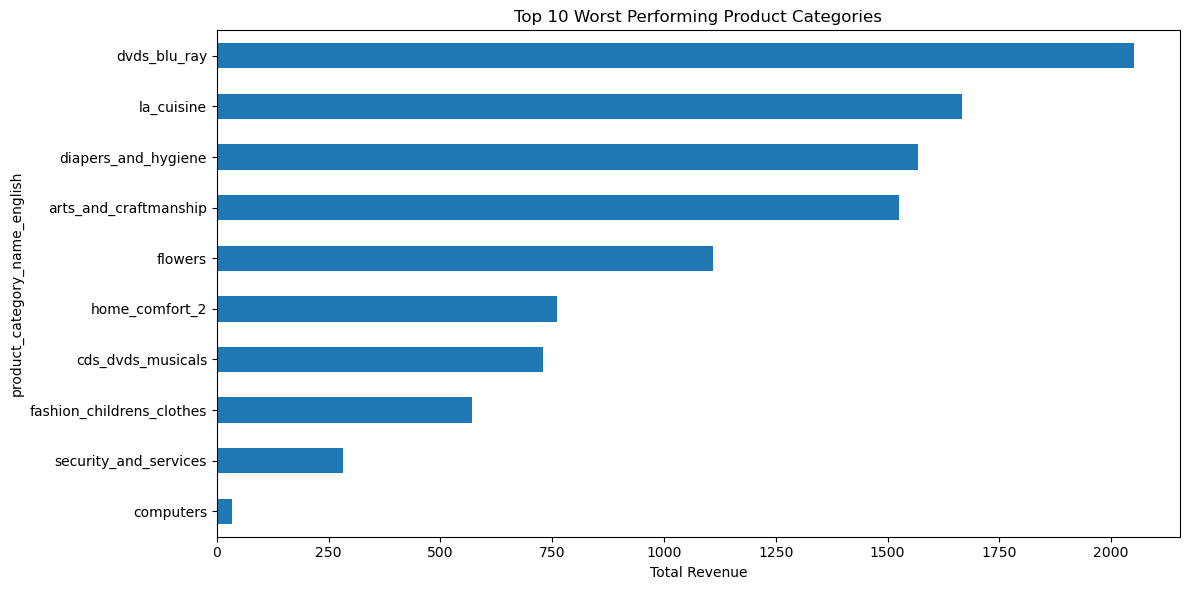

In [133]:
#  TOP 10 WORST PERFORMING PRODUCTS

worst_products = items_products.groupby("product_category_name_english")["price"].sum().sort_values(ascending=True).head(10)

plt.figure(figsize=(12, 6))
worst_products.plot(kind="barh")
plt.title("Top 10 Worst Performing Product Categories")
plt.xlabel("Total Revenue")
plt.tight_layout()
plt.show()


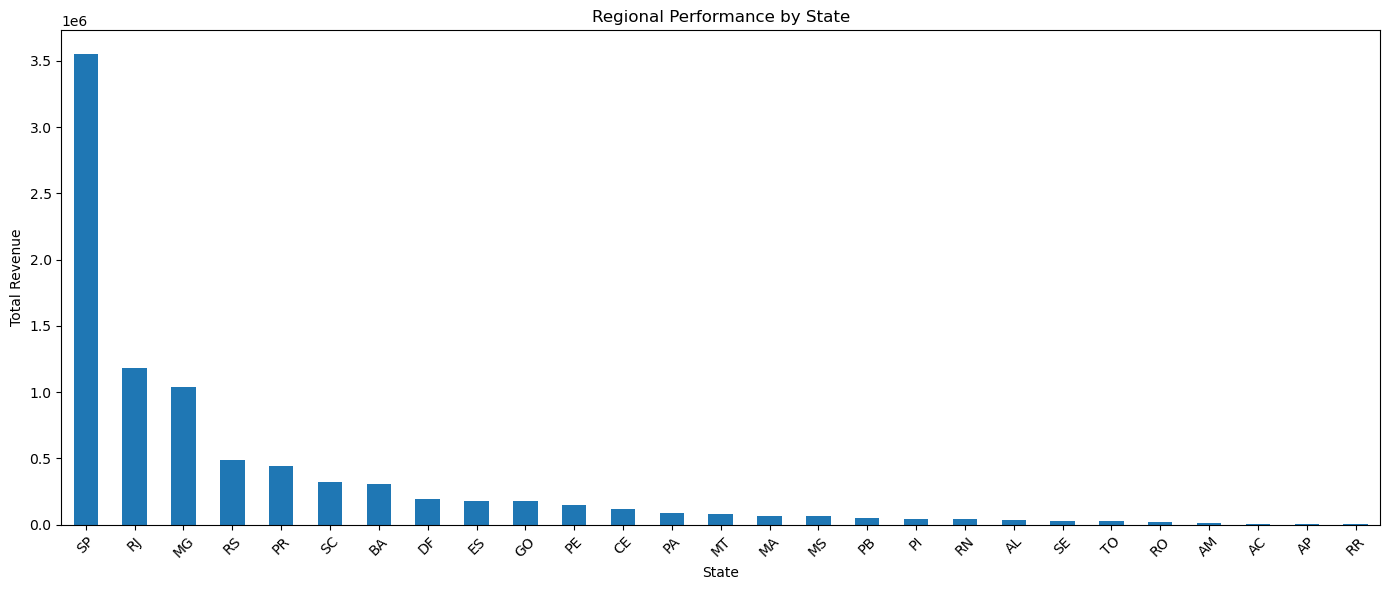

In [134]:
# REGIONAL PERFORMANCE BY STATE
# MERGING ORDERS, ITEMS AND CUSTOMERS
orders_items_customer = pd.merge(orders_items, customer, on="customer_id", how="inner")

# REGIONAL PERFORMANCE
regional = orders_items_customer.groupby("customer_state")["price"].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
regional.plot(kind="bar")
plt.title("Regional Performance by State")
plt.xlabel("State")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

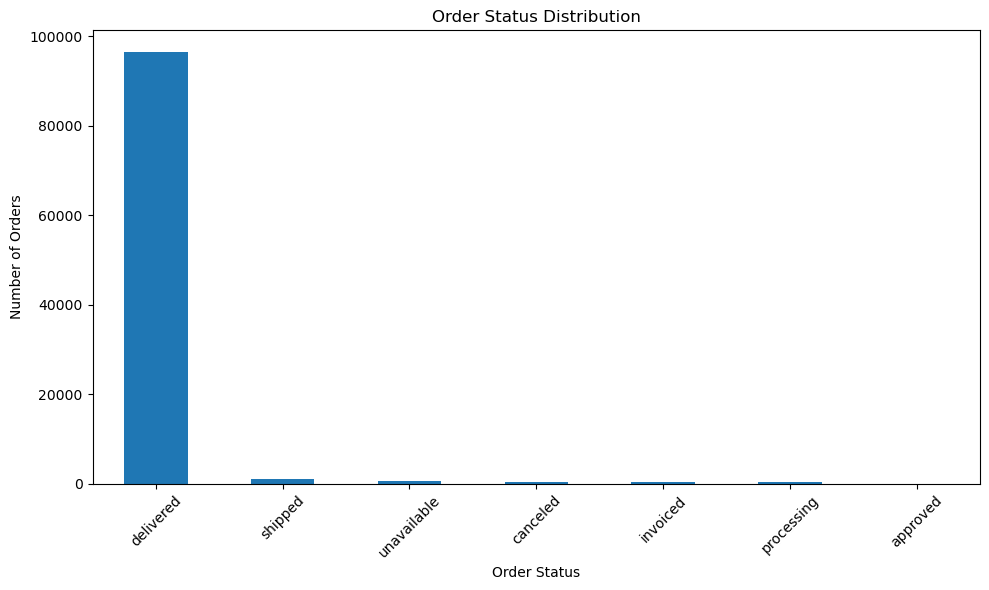

In [135]:
# ORDER STATUS DISTRIBUTION
order_status = orders["order_status"].value_counts()

plt.figure(figsize=(10, 6))
order_status.plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

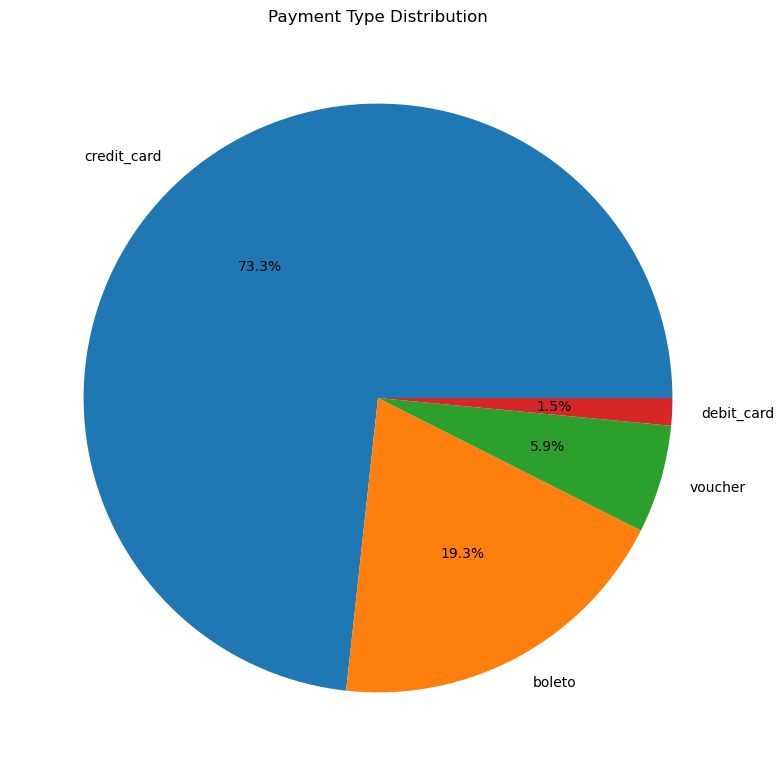

In [136]:
# PAYMENT TYPE DISTRIBUTION

payment_type = payment["payment_type"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(payment_type.values, labels=payment_type.index, autopct="%1.1f%%")
plt.title("Payment Type Distribution")
plt.tight_layout()
plt.show()

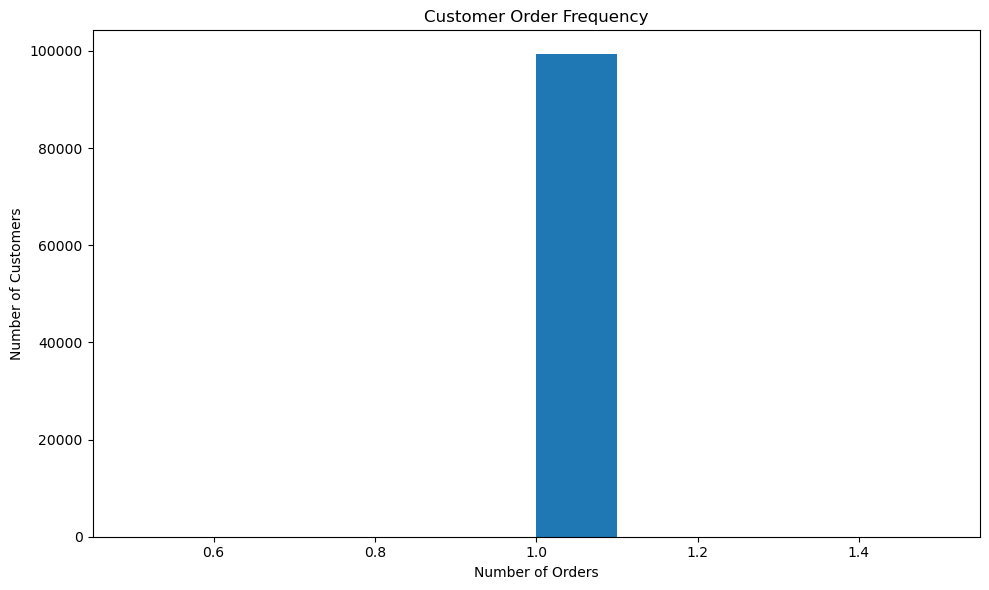

In [137]:
# CUSTOMER ORDER FREQUENCY
customer_frequency = orders.groupby("customer_id")["order_id"].count()

plt.figure(figsize=(10, 6))
plt.hist(customer_frequency.values, bins=10)
plt.title("Customer Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

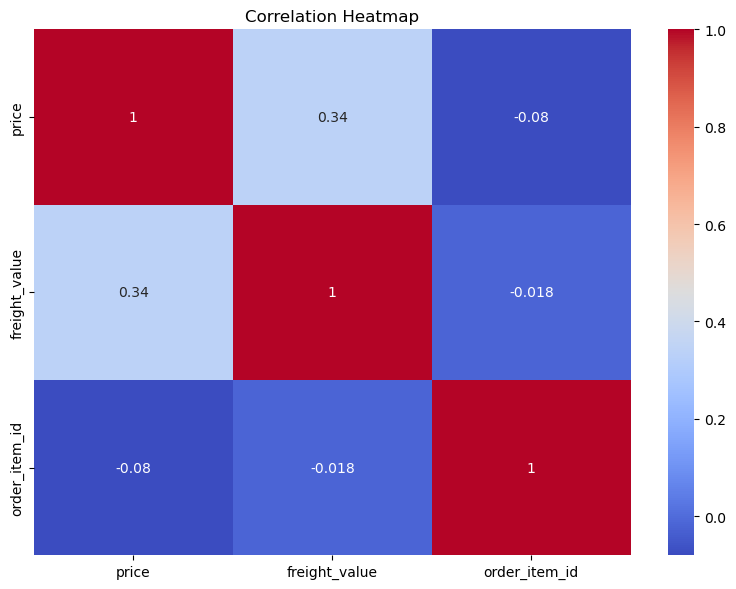

In [138]:
# CORRELATION HEATMAP
plt.figure(figsize=(8, 6))
sns.heatmap(items[["price", "freight_value", "order_item_id"]].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Step 1 — Merge datasets
- Merged orders, items and customers into one dataframe (`customer_orders`)
- Used inner join on `order_id` and `customer_id`
- Result: 104,210 rows × 18 columns

### Step 2 — Calculate Raw RFM Metrics
- `recency` — most recent order date per customer using groupby + max
- `frequency` — number of orders per customer using groupby + count
- `monetary` — total spend per customer using groupby + sum
- Combined all three into one `rfm` dataframe using `pd.concat(axis=1)`
- Converted recency from date to number of days using a reference date and `.dt.days`

### Step 3 — Score Each Metric (1–5)
- Used `pd.qcut` to split each metric into 5 equal buckets
- `recency_score` — reversed labels [5,4,3,2,1] because fewer days = better customer
- `frequency_score` — used `.rank(method='first')` to handle duplicate values
- `monetary_score` — higher spend = higher score
- Combined all three scores into one `rfm_score` column (range 3–15)

### Step 4 — Segment Customers
- Defined a function `segment_customer()` to assign segments based on rfm_score
- Score >= 12 → Premium
- Score >= 9 → Regular
- Score >= 6 → Needs Attention
- Else → Churned

### Segment Results
- Premium — 15,357 customers (recent, frequent, high spend)
- Regular — 34,251 customers (occasional buyers)
- Needs Attention — 30,384 customers (engagement dropping)
- Churned — 7,771 customers (inactive, low engagement)

### Step 5 — Churn Probability Scoring
- Used min-max normalisation on recency to scale churn probability between 0 and 1
- Higher recency days = higher churn probability
- Formula: `(recency - min) / (max - min)`
    
      
      

In [139]:
items.info()

<class 'pandas.core.frame.DataFrame'>
Index: 104223 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             104223 non-null  object        
 1   order_item_id        104223 non-null  int64         
 2   product_id           104223 non-null  object        
 3   seller_id            104223 non-null  object        
 4   shipping_limit_date  104223 non-null  datetime64[ns]
 5   price                104223 non-null  float64       
 6   freight_value        104223 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.4+ MB


In [140]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99281 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99281 non-null  object        
 1   customer_id                    99281 non-null  object        
 2   order_status                   99281 non-null  object        
 3   order_purchase_timestamp       99281 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97644 non-null  datetime64[ns]
 6   order_delivered_customer_date  96462 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99281 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.8+ MB


In [141]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [142]:
merge = pd.merge(orders,items, on = "order_id", how = "inner")

In [143]:
customer_orders = pd.merge (merge, customer, on = "customer_id", how = "inner")

In [144]:
customer_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104210 entries, 0 to 104209
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       104210 non-null  object        
 1   customer_id                    104210 non-null  object        
 2   order_status                   104210 non-null  object        
 3   order_purchase_timestamp       104210 non-null  datetime64[ns]
 4   order_approved_at              104210 non-null  datetime64[ns]
 5   order_delivered_carrier_date   103205 non-null  datetime64[ns]
 6   order_delivered_customer_date  102054 non-null  datetime64[ns]
 7   order_estimated_delivery_date  104210 non-null  datetime64[ns]
 8   order_item_id                  104210 non-null  int64         
 9   product_id                     104210 non-null  object        
 10  seller_id                      104210 non-null  object        
 11  

In [145]:
customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [146]:
#RECENCY
# BTHIS IS HOW RECENTLY A CUSTOMER MADE A PURCHASE OR INTERACTED
recency = customer_orders.groupby("customer_unique_id")["order_purchase_timestamp"].max()

In [147]:
#FREQUENCY
#THIS IS HOW OFTEN  THE CUSTOMER MADE PURCHASE
frequency = customer_orders.groupby("customer_unique_id")["order_id"].count()

In [148]:
# MONETARY
#HOW MUCH MONEY THE CUSTOMER SPEND
monetary = customer_orders.groupby("customer_unique_id")["price"].sum()

In [149]:
#customer_id — generated per order. If the same person places 3 orders, they get 3 different customer_id values
#customer_unique_id — the actual person. That same person across all 3 orders has the same customer_unique_id

#For RFM you want one row per person, not one row per order — so you group by customer_unique_id.

In [150]:
rfm = pd.concat([recency, frequency, monetary], axis = 1) #JOINED THE THREE TO ONE VARIABLE

In [151]:
rfm.head()

,order_purchase_timestamp,order_id,price
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00


In [152]:
rfm.columns

Index(['order_purchase_timestamp', 'order_id', 'price'], dtype='object')

In [153]:
rfm.rename(columns = {'order_purchase_timestamp' : 'recency',
                      'order_id' : 'frequency',
                      'price' : 'monetary'
                     }, inplace = True) #RENAME THE COLUMNS

In [154]:
rfm.head()

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00


In [155]:
reference_date = rfm["recency"].max() # Get the most recent order date in the dataset as our reference point

In [156]:
# Calculate how many days ago each customer last ordered
rfm["recency"] = (reference_date - rfm["recency"]).dt.days
#.dt.days converts the result from a timedelta (e.g. "116 days 04:32:11") into a plain integer (116).
#When you subtract two dates in pandas you get a timedelta — which includes hours, minutes and seconds. 
#.dt.days strips all that and gives you just the number of days as a clean number.

In [157]:
rfm.head()

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90
0000f46a3911fa3c0805444483337064,541,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99
0004aac84e0df4da2b147fca70cf8255,292,1,180.00


In [158]:
# Score Recency — lower days = more recent = better score (5 is best)
rfm['recency_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1])

# Score Frequency — higher frequency = better score (5 is best)
rfm['frequency_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Score Monetary — higher spend = better score (5 is best)
rfm['monetary_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5])

rfm.head()

,recency,frequency,monetary,recency_score,frequency_score,monetary_score
customer_unique_id,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90,4,1,4
0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90,4,1,1
0000f46a3911fa3c0805444483337064,541,1,69.00,1,1,3
0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99,2,1,1
0004aac84e0df4da2b147fca70cf8255,292,1,180.00,2,1,5


In [159]:
#combine the three scores into one single column
rfm['rfm_score'] = rfm['recency_score'].astype(int) + rfm['frequency_score'].astype(int) + rfm['monetary_score'].astype(int)

In [160]:
rfm.head()

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90,4,1,4,9
0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90,4,1,1,6
0000f46a3911fa3c0805444483337064,541,1,69.00,1,1,3,5
0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99,2,1,1,4
0004aac84e0df4da2b147fca70cf8255,292,1,180.00,2,1,5,8


In [161]:
# SEGMENT CUSTOMER BASED ON RFM SCORES
def segment_customer(score):
    if score >= 12:
        return "Premium"
    elif score >= 9:
        return "Regular"
    elif score >= 6:
        return "Needs Attention"
    else:
        return "Churned"
rfm["segment"] = rfm["rfm_score"].apply(segment_customer)

rfm["segment"].value_counts

<bound method IndexOpsMixin.value_counts of customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2            Regular
0000b849f77a49e4a4ce2b2a4ca5be3f    Needs Attention
0000f46a3911fa3c0805444483337064            Churned
0000f6ccb0745a6a4b88665a16c9f078            Churned
0004aac84e0df4da2b147fca70cf8255    Needs Attention
                                         ...       
fffbf87b7a1a6fa8b03f081c5f51a201            Premium
fffea47cd6d3cc0a88bd621562a9d061            Regular
ffff371b4d645b6ecea244b27531430a            Regular
ffff5962728ec6157033ef9805bacc48            Premium
ffffd2657e2aad2907e67c3e9daecbeb    Needs Attention
Name: segment, Length: 87763, dtype: object>

In [162]:
rfm.head()

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,segment
customer_unique_id,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90,4,1,4,9,Regular
0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90,4,1,1,6,Needs Attention
0000f46a3911fa3c0805444483337064,541,1,69.00,1,1,3,5,Churned
0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99,2,1,1,4,Churned
0004aac84e0df4da2b147fca70cf8255,292,1,180.00,2,1,5,8,Needs Attention


In [163]:
# CALCULATE CHURN PROBABILITY BASED ON RECENCY
# HIGHER RECENCY DAYS = HIGHER CHANCE OF CHURNING

rfm['churn_probability'] = (rfm['recency'] - rfm['recency'].min()) / (rfm['recency'].max() - rfm['recency'].min())

rfm.head()

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,segment,churn_probability
customer_unique_id,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90,4,1,4,9,Regular,0.157967
0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90,4,1,1,6,Needs Attention,0.162088
0000f46a3911fa3c0805444483337064,541,1,69.00,1,1,3,5,Churned,0.743132
0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99,2,1,1,4,Churned,0.446429
0004aac84e0df4da2b147fca70cf8255,292,1,180.00,2,1,5,8,Needs Attention,0.401099


In [164]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  object        
 4   review_comment_message   99224 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [165]:
merge = pd.merge(orders, items, how = "inner", on = "order_id")

In [166]:
merge1 = pd.merge(merge, payment, how = "inner", on = "order_id")

In [167]:
merge2 = pd.merge(merge1, customer, how = "inner", on = "customer_id")

In [168]:
merge3 = pd.merge(merge2, products, how = "inner", on = "product_id")

In [169]:
merge4 = pd.merge(merge3, sellers, how = "inner", on = "seller_id")

In [170]:
master_df = pd.merge(merge4, reviews, how = "left", on = "order_id") 
#not every order has a review and we don't want to lose rows because of missing reviews

master_df.info()

##  Preprocessing

### Master DataFrame
Merged 7 datasets into one master dataframe:
orders, items, payment, customer, products, sellers, reviews
Final shape: 104,805 rows × 39 columns

### Feature Engineering
Created 4 new columns:
- delivery_time: days between purchase and delivery
- total_order_value: price + freight value
- order_month: month extracted from purchase timestamp
- order_year: year extracted from purchase timestamp

### Target Variables
- Churn model: churn column (1 = Churned, 0 = Not Churned)
- Sales forecasting: total_order_value
- Demand prediction: order_month

### Feature Selection
Selected 16 features relevant to ML models.
Dropped irrelevant columns like IDs, timestamps and free text.

### Train/Test Split
80% training — 83,844 rows
20% testing — 20,961 rows
random_state= 42 for reproducibility

### Encoding
Label encoded 5 categorical columns:
order_status, payment_type, customer_state,  seller_state, product_category_name

### Scaling
Applied StandardScaler — fit on train only, transformed both train and test to avoid data leakage

In [171]:
#Your existing columns tell you what happened.
#Your new columns tell you how and when it happened.
#ML models need both to make accurate predictions.

In [172]:
# FEATURE ENGINEERING

# Delivery time in days
master_df["delivery_time"] = (master_df["order_delivered_customer_date"] - master_df["order_purchase_timestamp"]).dt.days

# Total order value
master_df["total_order_value"] = master_df["price"] + master_df["freight_value"]

# Order month
master_df["order_month"] = master_df["order_purchase_timestamp"].dt.month

# Order year
master_df["order_year"] = master_df["order_purchase_timestamp"].dt.year

In [173]:
master_df[["delivery_time", "total_order_value", "order_month", "order_year"]].head()

,delivery_time,total_order_value,order_month,order_year
0,8.0,38.71,10,2017
1,8.0,38.71,10,2017
2,8.0,38.71,10,2017
3,13.0,141.46,7,2018
4,9.0,179.12,8,2018


In [174]:
# DEFINE TARGET VARIABLES

# 1. CHURN MODEL TARGET
# Map RFM segments to binary; 1 = Churned, 0 = Not Churned
master_df["churn"] = master_df["customer_unique_id"].map(
    rfm["segment"].map({"Churned": 1, "Premium": 0, "Regular": 0, "Needs Attention": 0})
)

# 2. SALES FORECASTING TARGET
# total_order_value already exists from feature engineering 

# 3. DEMAND PREDICTION TARGET
# order_month already exists from feature engineering 


In [175]:
# CONFIRM CHURN COLUMN
master_df[["customer_unique_id", "churn"]].head(10)

,customer_unique_id,churn
0,7c396fd4830fd04220f754e42b4e5bff,0
1,7c396fd4830fd04220f754e42b4e5bff,0
2,7c396fd4830fd04220f754e42b4e5bff,0
3,af07308b275d755c9edb36a90c618231,0
4,3a653a41f6f9fc3d2a113cf8398680e8,0
5,7c142cf63193a1473d2e66489a9ae977,0
6,72632f0f9dd73dfee390c9b22eb56dd6,0
7,80bb27c7c16e8f973207a5086ab329e2,0
8,36edbb3fb164b1f16485364b6fb04c73,1
9,932afa1e708222e5821dac9cd5db4cae,0


In [176]:
# FEATURE SELECTION
features = [
    "order_month",
    "order_year", 
    "delivery_time",
    "total_order_value",
    "payment_value",
    "payment_installments",
    "price",
    "freight_value",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "review_score",
    "order_status",
    "payment_type",
    "customer_state",
    "seller_state",
    "product_category_name"  # changed from product_category_name_english
]



In [177]:
# CREATE MODEL DATAFRAME
model_df = master_df[features + ["churn"]].copy()


In [178]:
# CHECK FOR NULLS
model_df.isnull().sum()

order_month                 0
order_year                  0
delivery_time            2170
total_order_value           0
payment_value               0
payment_installments        0
price                       0
freight_value               0
product_weight_g            0
product_length_cm           0
product_height_cm           0
product_width_cm            0
review_score              830
order_status                0
payment_type                0
customer_state              0
seller_state                0
product_category_name       0
churn                       0
dtype: int64

In [179]:
# FILL MISSING DELIVERY TIME WITH MEDIAN
model_df["delivery_time"] = model_df["delivery_time"].fillna(model_df["delivery_time"].median())

# FILL MISSING REVIEW SCORE WITH MEDIAN
model_df["review_score"] = model_df["review_score"].fillna(model_df["review_score"].median())

In [180]:
# CONFIRM NO MORE NULLS
model_df.isnull().sum()

order_month              0
order_year               0
delivery_time            0
total_order_value        0
payment_value            0
payment_installments     0
price                    0
freight_value            0
product_weight_g         0
product_length_cm        0
product_height_cm        0
product_width_cm         0
review_score             0
order_status             0
payment_type             0
customer_state           0
seller_state             0
product_category_name    0
churn                    0
dtype: int64

In [181]:
# ENCODE CATEGORICAL VARIABLES
le = LabelEncoder()

In [182]:
#encode each categorical column
model_df["order_status"] = le.fit_transform(model_df["order_status"])
model_df["payment_type"] = le.fit_transform(model_df["payment_type"])
model_df["customer_state"] = le.fit_transform(model_df["customer_state"])
model_df["seller_state"] = le.fit_transform(model_df["seller_state"])
model_df["product_category_name"] = le.fit_transform(model_df["product_category_name"])

In [183]:
model_df.head()

,order_month,order_year,delivery_time,total_order_value,payment_value,payment_installments,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score,order_status,payment_type,customer_state,seller_state,product_category_name,churn
0,10,2017,8.0,38.71,18.12,1,29.99,8.72,500.0,19.0,8.0,13.0,4.0,2,1,25,22,73,0
1,10,2017,8.0,38.71,2.00,1,29.99,8.72,500.0,19.0,8.0,13.0,4.0,2,3,25,22,73,0
2,10,2017,8.0,38.71,18.59,1,29.99,8.72,500.0,19.0,8.0,13.0,4.0,2,3,25,22,73,0
3,7,2018,13.0,141.46,141.46,1,118.70,22.76,400.0,19.0,13.0,19.0,4.0,2,0,4,22,62,0
4,8,2018,9.0,179.12,179.12,3,159.90,19.22,420.0,24.0,19.0,21.0,5.0,2,1,8,22,8,0


##   Machine Learning

### Models Built
Three models were trained to support business decision making:
1. Churn Prediction — Random Forest Classifier
2. Sales Forecasting — Random Forest Regressor
3. Demand Prediction — Random Forest Regressor

### Churn Model Results
Initial Results:
- Accuracy: 92.4%
- Precision: 53.2%
- Recall: 30% — too low, missing most churned customers
- F1 Score: 38.3%
- ROC-AUC: 63.9%

After Hyperparameter Tuning:
- Accuracy: 85.4%
- Precision: 33.7%
- Recall: 89.4% — massive improvement
- F1 Score: 48.9%
- ROC-AUC: 87.2%

### Sales Forecasting Model Results
- MAE: 0.56
- RMSE: 1.34
- R2 Score: 99.95% — near perfect predictions

### Demand Prediction Model Results
- MAE: 1.77
- RMSE: 2.21
- R2 Score: 53.5% — acceptable, room for improvement

### Feature Importance Findings
- Churn: payment_value, price and delivery_time are biggest drivers
- Sales: price dominates at 95% importance
- Demand: order_year and freight_value are biggest drivers

### Hyperparameter Tuning
Applied to all 3 models:
- n_estimators increased to 200
- max_depth set to 10
- class_weight set to balanced for churn model
  to fix class imbalance and improve recall

### Models Saved
All 3 tuned models saved using joblib:
- churn_model.joblib
- sales_model.joblib
- demand_model.joblib

In [184]:
#churn model
X_churn = model_df.drop(columns = ["churn", "total_order_value", "order_month"])
y_churn = model_df["churn"]

In [185]:
X_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104805 entries, 0 to 104804
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_year             104805 non-null  int32  
 1   delivery_time          104805 non-null  float64
 2   payment_value          104805 non-null  float64
 3   payment_installments   104805 non-null  int64  
 4   price                  104805 non-null  float64
 5   freight_value          104805 non-null  float64
 6   product_weight_g       104805 non-null  float64
 7   product_length_cm      104805 non-null  float64
 8   product_height_cm      104805 non-null  float64
 9   product_width_cm       104805 non-null  float64
 10  review_score           104805 non-null  float64
 11  order_status           104805 non-null  int32  
 12  payment_type           104805 non-null  int32  
 13  customer_state         104805 non-null  int32  
 14  seller_state           104805 non-nu

In [186]:
y_churn.info()

<class 'pandas.core.series.Series'>
RangeIndex: 104805 entries, 0 to 104804
Series name: churn
Non-Null Count   Dtype
--------------   -----
104805 non-null  int64
dtypes: int64(1)
memory usage: 818.9 KB


In [187]:
# SALES FORECASTING MODEL
X_sales = model_df.drop(columns =["churn", "total_order_value", "order_month"])
y_sales = model_df["total_order_value"]

In [188]:
# Demand prediction model
X_demand = model_df.drop(columns = ["churn", "total_order_value", "order_month"])
y_demand = model_df["order_month"]

In [189]:
# TRAIN TEST SPLIT

In [190]:
X_churn_train, X_churn_test, y_churn_train, y_churn_test = train_test_split(X_churn, y_churn, test_size = 0.2, random_state = 42)

In [191]:
X_sales_train, X_sales_test, y_sales_train, y_sales_test = train_test_split(X_sales, y_sales, test_size = 0.2, random_state = 42)

In [192]:
X_demand_train, X_demand_test, y_demand_train, y_demand_test = train_test_split(X_demand, y_demand, test_size = 0.2, random_state = 42)

In [193]:
#confirm shapes
print("Churn Train", X_churn_train.shape, "Test", X_churn_test.shape)
print("Sales Train", X_sales_train.shape, "Test", X_sales_test.shape)
print("Demand Train", X_demand_train.shape, "Test", X_demand_test.shape)

Churn Train (83844, 16) Test (20961, 16)
Sales Train (83844, 16) Test (20961, 16)
Demand Train (83844, 16) Test (20961, 16)


In [194]:
# INITIALIZE SCALER
scaler = StandardScaler()

In [195]:
from sklearn.preprocessing import StandardScaler

# INITIALIZE SCALER
scaler = StandardScaler()

# FIT ON TRAIN DATA ONLY — THEN TRANSFORM BOTH TRAIN AND TEST
X_churn_train = scaler.fit_transform(X_churn_train)
X_churn_test = scaler.transform(X_churn_test)

X_sales_train = scaler.fit_transform(X_sales_train)
X_sales_test = scaler.transform(X_sales_test)

X_demand_train = scaler.fit_transform(X_demand_train)
X_demand_test = scaler.transform(X_demand_test)

print("Scaling complete")

Scaling complete


In [196]:
#INITIALIZE CHURN MODEL
churn_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

#TRAIN THE MODEL
churn_model.fit(X_churn_train, y_churn_train)

#make predictions
prediction = churn_model.predict(X_churn_test)

#Evaluate
print("Accuracy", accuracy_score(y_churn_test, prediction))
print("Precision", precision_score(y_churn_test, prediction))
print("Recall", recall_score(y_churn_test, prediction))
print("F1 score", f1_score(y_churn_test, prediction))
print("ROC-AUC", roc_auc_score(y_churn_test, prediction))




Accuracy 0.9244787939506703
Precision 0.5318918918918919
Recall 0.29963459196102316
F1 score 0.38332684067004286
ROC-AUC 0.6386107117887831


In [197]:
#INITIALIZE SALES MODEL
sales_model = RandomForestRegressor(n_estimators = 100, random_state = 42)

#TRAIN THE MODEL
sales_model.fit(X_sales_train, y_sales_train)

# Make predictions
prediction =  sales_model.predict(X_sales_test)

#Evaluate
print("MAE", mean_absolute_error(y_sales_test, prediction))
print("RMSE", np.sqrt(mean_squared_error(y_sales_test, prediction)))
print("R2 Score", r2_score(y_sales_test, prediction))


MAE 0.1404714278899041
RMSE 1.0937688516582402
R2 Score 0.999690584396266


In [198]:
#INITIALIZE DEMAND MODEL
demand_model = RandomForestRegressor(n_estimators = 100, random_state = 42)

#TRAIN THE MODEL
demand_model.fit(X_demand_train, y_demand_train)

# Make predictions
prediction =  demand_model.predict(X_demand_test)

#Evaluate
print("MAE", mean_absolute_error(y_demand_test, prediction))
print("RMSE", np.sqrt(mean_squared_error(y_demand_test, prediction)))
print("R2 Score", r2_score(y_demand_test, prediction))

MAE 1.282689199924852
RMSE 1.7487795537057682
R2 Score 0.7075682348923665


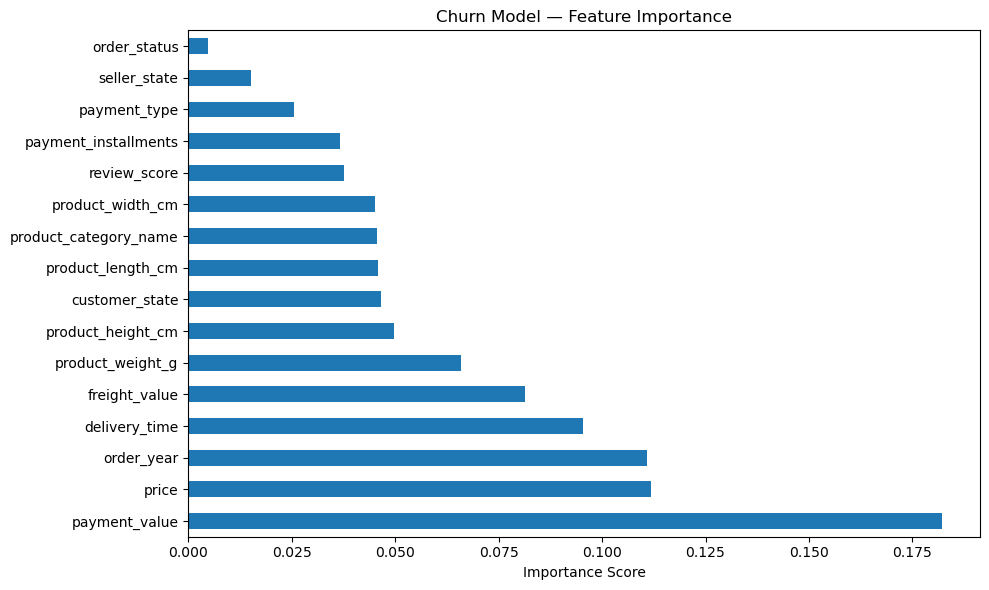

In [199]:
# CHURN MODEL FEATURE IMPORTANCE

# Get the column names from model_df excluding target columns
# These are the 16 features we used to train the model
feature_names = model_df.drop(columns=["churn", "total_order_value", "order_month"]).columns

# feature_importances_ is a built-in attribute of Random Forest
# It gives each feature a score showing how much it contributed to predictions
# pd.Series pairs each score with its feature name
# sort_values sorts from highest to lowest importance
churn_importance = pd.Series(churn_model.feature_importances_, index=feature_names).sort_values(ascending=False)

# Plot as horizontal bar chart
plt.figure(figsize=(10, 6))
churn_importance.plot(kind="barh")
plt.title("Churn Model — Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

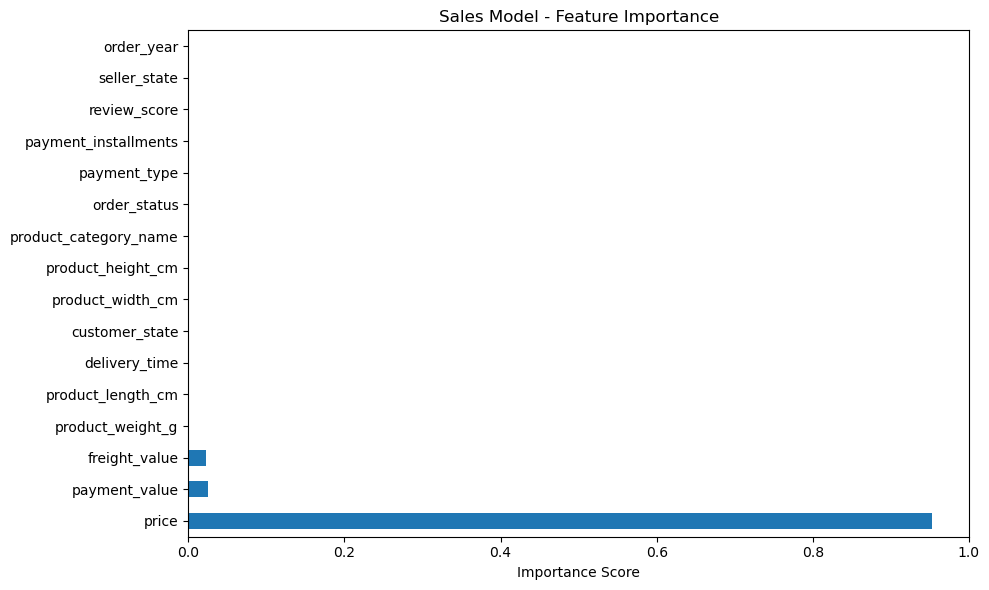

In [200]:
# SALES MODEL FEATURE IMPORTANCE

feature_names = model_df.drop(columns=["churn", "total_order_value", "order_month"]).columns

sales_importance = pd.Series(sales_model.feature_importances_, index = feature_names).sort_values(ascending=False)

# plot as horizontsl bar chat
plt.figure(figsize=(10,6))
sales_importance.plot(kind = "barh")
plt.title("Sales Model - Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


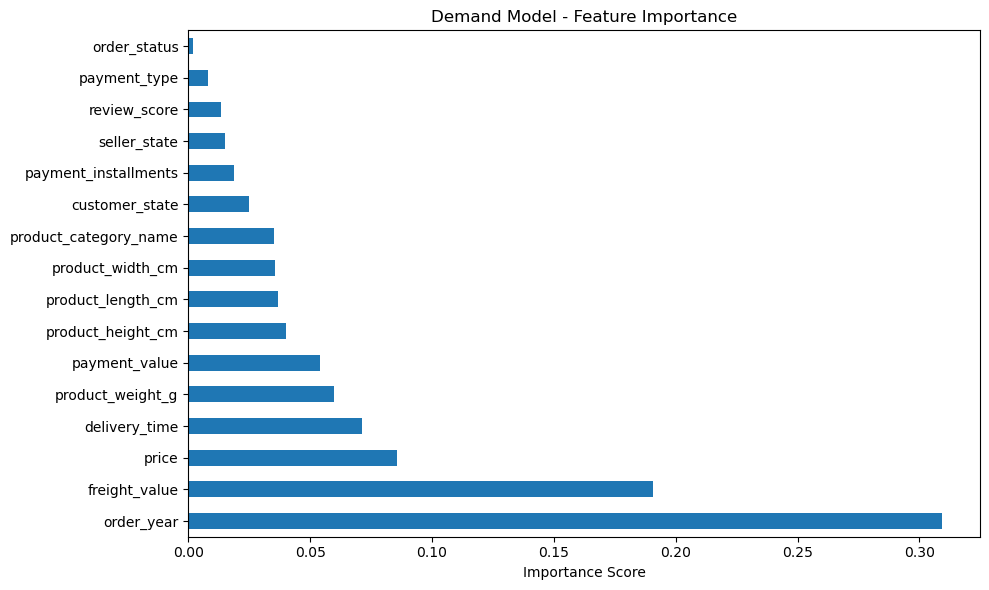

In [201]:
# DEMAND  MODEL FEATURE IMPORTANCE

feature_names = model_df.drop(columns=["churn", "total_order_value", "order_month"]).columns

demand_importance = pd.Series(demand_model.feature_importances_, index = feature_names).sort_values(ascending=False)

# plot as horizontsl bar chat
plt.figure(figsize=(10,6))
demand_importance.plot(kind = "barh")
plt.title("Demand Model - Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [202]:
# HYPERPARAMETER TUNING — CHURN MODEL
# class_weight='balanced' fixes class imbalance — churned customers are a minority
# so the model was ignoring them, causing low recall
churn_model_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

churn_model_tuned.fit(X_churn_train, y_churn_train)
y_churn_pred_tuned = churn_model_tuned.predict(X_churn_test)

print("TUNED CHURN MODEL RESULTS")
print(f"Accuracy:  {accuracy_score(y_churn_test, y_churn_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_churn_test, y_churn_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_churn_test, y_churn_pred_tuned):.4f}")
print(f"F1 Score:  {f1_score(y_churn_test, y_churn_pred_tuned):.4f}")
print(f"ROC -AUC:  {roc_auc_score(y_churn_test, y_churn_pred_tuned):.4f}")


TUNED CHURN MODEL RESULTS
Accuracy:  0.8540
Precision: 0.3372
Recall:    0.8940
F1 Score:  0.4897
ROC -AUC:  0.8723


In [203]:
# HYPERPARAMETER TUNING — SALES MODEL
sales_model_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

sales_model_tuned.fit(X_sales_train, y_sales_train)
y_sales_pred_tuned = sales_model_tuned.predict(X_sales_test)

print("TUNED SALES MODEL RESULTS")
print(f"MAE:  {mean_absolute_error(y_sales_test, y_sales_pred_tuned):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_sales_test, y_sales_pred_tuned)):.4f}")
print(f"R2:   {r2_score(y_sales_test, y_sales_pred_tuned):.4f}")

TUNED SALES MODEL RESULTS
MAE:  0.5611
RMSE: 1.3404
R2:   0.9995


In [204]:
# HYPERPARAMETER TUNING — DEMAND MODEL
demand_model_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

demand_model_tuned.fit(X_demand_train, y_demand_train)
y_demand_pred_tuned = demand_model_tuned.predict(X_demand_test)

print("TUNED DEMAND MODEL RESULTS")
print(f"MAE:  {mean_absolute_error(y_demand_test, y_demand_pred_tuned):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_demand_test, y_demand_pred_tuned)):.4f}")
print(f"R2:   {r2_score(y_demand_test, y_demand_pred_tuned):.4f}")

TUNED DEMAND MODEL RESULTS
MAE:  1.7689
RMSE: 2.2050
R2:   0.5351


In [205]:
# save the model
joblib.dump(churn_model_tuned, "churn_model.joblib")
joblib.dump(sales_model_tuned, "sales_model.joblib")
joblib.dump(demand_model_tuned, "demand_model.joblib")

print("ALL SAVED SUCCESFULLY")

ALL SAVED SUCCESFULLY


## AI Insight Generator

### What it does
Automatically reads business metrics and generates plain English insights
and recommendations without a human manually interpreting the data.

### Tool Used
- Groq API — free alternative to Claude/OpenAI
- Model: llama-3.3-70b-versatile

### Data Fed into the AI
- Customer segment distribution (Premium, Regular, Needs Attention, Churned)
- Total revenue, average order value, total orders
- Churn summary — total churned customers and average churn probability
- ML model performance scores (Churn, Sales, Demand)

### AI Generated Insights
1. Regular segment is the largest at 43% of the customer base (34,251 customers)
2. Average order value is low at ₦83.98 — upselling opportunity exists
3. Average churn probability of 0.33 — 33% of customers at risk
4. Churn model recall of 89% — strong at identifying at-risk customers
5. Needs Attention segment is 33% of base — requires urgent retention strategy

### AI Generated Recommendations
1. Targeted retention strategies for Needs Attention and Churned segments
2. Upselling and cross-selling strategies for Premium segment
3. Improve demand forecasting model — current R2 of 53.51% needs work

### Key Takeaway
Instead of a human reading charts and writing reports, the AI reads the raw numbers and generates a full business report automatically — making this system usable by non-technical business managers

In [206]:


# INITIALIZE GROQ CLIENT
client = Groq(api_key="YOUR_GROQ_API_KEY_HERE")

# PREPARE BUSINESS METRICS TO SEND TO AI
metrics_summary = f"""
You are a business intelligence analyst for a Nigerian e-commerce company similar to Jumia.
Analyze the following business metrics and generate clear, actionable insights in plain English.

CUSTOMER SEGMENTS:
{rfm['segment'].value_counts().to_string()}

REVENUE SUMMARY:
- Total Revenue: {customer_orders['price'].sum():,.2f}
- Average Order Value: {customer_orders['price'].mean():,.2f}
- Total Orders: {customer_orders['order_id'].nunique()}

CHURN SUMMARY:
- Total Churned Customers: {rfm[rfm['segment'] == 'Churned'].shape[0]}
- Average Churn Probability: {rfm['churn_probability'].mean():.2f}

ML MODEL PERFORMANCE:
- Churn Model Recall: 89%
- Sales Forecast R2: 99.95%
- Demand Prediction R2: 53.51%

Generate 5 key business insights and 3 recommendations based on this data.
"""

# SEND TO GROQ AND GET RESPONSE
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {"role": "user", "content": metrics_summary}
    ]
)

# PRINT THE AI GENERATED INSIGHTS
print(response.choices[0].message.content)

**Key Business Insights:**

1. **Customer Segment Analysis**: The company has a large base of regular customers (34,251), but a significant portion of customers (30,384) are labeled as "Needs Attention", indicating potential retention issues. The premium customer segment is relatively small (15,357) but likely generates higher revenue.
2. **Revenue Performance**: The company has generated a substantial total revenue of ₦8.75 billion, with an average order value of ₦83.98. This suggests that customers are making relatively small purchases, and there may be opportunities to increase average order value through upselling or bundling.
3. **Churn Risk**: The average churn probability is 0.33, indicating that approximately one-third of customers are at risk of churning. The total number of churned customers (7,771) represents a significant loss of revenue potential.
4. **Model Performance**: The churn model has a high recall of 89%, indicating that it is effective in identifying customers wh

## Recommendation Engine

### What it does
Automatically assigns a business recommendation to every customer based on their RFM segment — no human interpretation needed.

### Logic
Used a dictionary to map each segment to a tailored recommendation, then applied it to all customers in one line using `.map()`

### Recommendations by Segment
- Premium → Reward with loyalty program, offer exclusive deals and early access to new products
- Regular → Encourage repeat purchases with discount codes and personalised product suggestions
- Needs Attention → Send win-back offer, highlight new arrivals and offer free shipping incentive
- Churned → Last chance re-engagement — send strong discount offer and request feedback

### Output
Every customer in the rfm dataframe now has a personalised recommendation attached to their profile based on their segment

In [207]:
# RECOMMENDATION ENGINE
# Map each customer segment to a business recommendation
recommendations = {
    'Premium': 'Reward with loyalty program, offer exclusive deals and early access to new products',
    'Regular': 'Encourage repeat purchases with discount codes and personalised product suggestions',
    'Needs Attention': 'Send win-back offer, highlight new arrivals and offer free shipping incentive',
    'Churned': 'Last chance re-engagement — send strong discount offer and request feedback'
}

# Apply recommendation to every customer based on their segment
rfm['recommendation'] = rfm['segment'].map(recommendations)

rfm[['segment', 'recommendation']].head(10)

,segment,recommendation
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,Regular,Encourage repeat purchases with discount codes...
0000b849f77a49e4a4ce2b2a4ca5be3f,Needs Attention,"Send win-back offer, highlight new arrivals an..."
0000f46a3911fa3c0805444483337064,Churned,Last chance re-engagement — send strong discou...
0000f6ccb0745a6a4b88665a16c9f078,Churned,Last chance re-engagement — send strong discou...
0004aac84e0df4da2b147fca70cf8255,Needs Attention,"Send win-back offer, highlight new arrivals an..."
0004bd2a26a76fe21f786e4fbd80607f,Regular,Encourage repeat purchases with discount codes...
00050ab1314c0e55a6ca13cf7181fecf,Needs Attention,"Send win-back offer, highlight new arrivals an..."
00053a61a98854899e70ed204dd4bafe,Premium,"Reward with loyalty program, offer exclusive d..."
0005e1862207bf6ccc02e4228effd9a0,Needs Attention,"Send win-back offer, highlight new arrivals an..."


##  SQL Integration


### Connection
Connected Python to MySQL database using SQLAlch my
and mysql-connector-python.
Special characters in password handled using quote plus
from urllib.parse.

### Data Pushed
Master dataframe pushed directly from Python to MySQL
without manual CSV importing.
Table name: master_table
Rows: 101,477
Columns: 39

### Approach
Used pandas .to_sql() method t  push dataframe
directly into MySQL — faster a d more efficient
than manual file importing.

In [208]:
# CONNECT TO MYSQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Somide0987+",
    database="business"
)

print("Connected to MySQL successfully ✅")

Connected to MySQL successfully ✅


In [217]:
# PUSH MASTER TABLE IN CHUNKS
with engine.begin() as conn:
    master_df.to_sql(
        "master_table", 
        con=conn, 
        if_exists="replace", 
        index=False,
        chunksize=5000
    )
    print("master_table pushed ✅")

# PUSH RFM TABLE
with engine.begin() as conn:
    rfm.to_sql(
        "rfm_table", 
        con=conn, 
        if_exists="replace", 
        index=False,
        chunksize=5000
    )
    print("rfm_table pushed ✅")

master_table pushed ✅
rfm_table pushed ✅


In [ ]:
# VERIFY DATA IN MYSQL
verify = pd.read_sql("SELECT COUNT(*) as total_rows FROM master_table", con=engine)
print(verify)

###  Result of Analytical Queries Run in MySQL

1. Total Revenue: 7,884,095
2. Top State by Revenue: SP (São Paulo) at 3.2M — 
   Brazil's commercial hub dominates all regions
3. Top Product Category: cama_mesa_banho (bed, bath, table)
   at 883k total revenue
4. Order Status: 99,406 out of 101,477 orders delivered —
   98% delivery success rate
5. Average Delivery Time: 11.81 days per order
6. Revenue Growth: consistent year on year growth
   from 2016 through 2018

### Key Observation
São Paulo generates nearly 40% of total revenue alone.
Logistics and marketing efforts should prioritise this region to maximise returns.

In [215]:
rfm.to_csv('rfm_segments.csv', index=True)

## Power BI Dashboard

### Data Source
Connected Power BI to master_table.csv and rfm_table.csv exported from Python pipeline.

### Dashboard Pages

#### Page 1 — Sales Overview
- Monthly revenue trend line chart
- Yearly revenue bar chart
- Total Revenue card: 8.52M
- Total Orders card: 105K

#### Page 2 — Product Performance
- Top 10 performing products — cama_mesa_banho leads
- Top 10 underperforming products — pcs is worst

#### Page 3 — Regional Performance
- Revenue by state horizontal bar chart
- SP dominates with 3.5M — nearly 40% of total revenue

#### Page 4 — Customer Intelligence
- Customer segments donut chart
  - Regular: 39.3%
  - Needs Attention: 35.16%
  - Premium: 16.55%
  - Churned: 8.99%
- Average Churn Probability: 0.33

#### Page 5 — Key Metrics
- Avg Order Value: 99.52
- Total Revenue: 8.52M
- Avg Delivery Time: 11.84 days
- Total Customers: 86K

### Key Business Insights
- Revenue grew consistently year on year
- SP state generates the most revenue by far
- 35% of customers need immediate retention attention
- Average delivery time of 11.84 days could be improved
- bed_bath_table category is the top revenue driver